In [41]:
import os
import sys
from parflow.tools import Run
from parflow.tools.fs import mkdir, cp, get_absolute_path, exists
from parflow.tools.settings import set_working_directory
from parflow.tools.io import read_pfb,write_pfb, read_clm
import parflow.tools.hydrology as hydro
import parflow as pf
from parflow import Run
import subsettools as st
from glob import glob
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import calendar
from matplotlib import colors 
import matplotlib.dates as mdates
import argparse
from sklearn.metrics import r2_score, mean_squared_error
import hf_hydrodata as hf
from matplotlib.patches import Rectangle

In [43]:
EC_data = pd.read_csv('~/model_validation/EddyCovariance_MeteorlogicalVariables_CrestedButtePumphouse.csv') # daily flux tower data
EC_metadata = pd.read_csv('~/model_validation/locations.csv') 

####### find model domain gridcell index corresponding to this tower
# from flux tower metadata
lon = EC_metadata['Longitude'].iloc[0]
lat = EC_metadata['Latitude'].iloc[0]

# Since we want to subset only a single location, both lat-lon bounds are defined by this point:
latlon_bounds = [[lat, lon],[lat, lon]]
ij_conus2_bounds, mask = st.define_latlon_domain(latlon_bounds=latlon_bounds, grid="conus2")
print(f"bounding box: {ij_conus2_bounds}")
# The mask contains a single point:
print(f"mask: {mask}")

# the coordinates in the etw will be different
# (imin, jmin, imax, jmax)
#etw_bounds, _ = st.define_huc_domain(hucs=['14020001'], grid='conus2') 
etw_bounds = (1359, 1569, 1426, 1617) # original domain bounds before update
print('etw bounds', etw_bounds)

i_etw = ij_conus2_bounds[0] - etw_bounds[0]
j_etw = ij_conus2_bounds[1] - etw_bounds[1]

ec_ij_coords = (i_etw, j_etw)
print(ec_ij_coords)

bounding box: (1373, 1604, 1374, 1605)
mask: [[1]]
etw bounds (1359, 1569, 1426, 1617)
(14, 35)


# WY2017

In [44]:
water_year = 2017
runname = 'baseline.wy2017'

In [45]:
########## subset the flux data to the right water year
EC_data['DAY_MT'] = pd.to_datetime(EC_data['DAY_MT'])

EC_data_wy = EC_data[(EC_data['DAY_MT'] >= pd.to_datetime(f'{water_year - 1}-10-01')) & (EC_data['DAY_MT'] <= pd.to_datetime(f'{water_year}-09-30'))]

######## get pf out ET from run
path_run = f'~/{runname}/'

run = Run.from_definition(f'{path_run}{runname}.pfidb')

data = run.data_accessor # creating data accessor object 
dx = data.dx
dy = data.dy
dz = data.dz

nz,ny,nx = data.shape
mask = data.mask
mask[mask>0]=1 # PF has big # instead of 1 so change to 1 bc more manageable
surf_mask = mask[-1,:,:] # last element of first axis (always be surface no matter what)
nanmask=mask.copy()
nanmask[nanmask == 0] = 'NaN'
nanmask[nanmask > 0] = 1

# for converting from LE to ET
rho_w = 1000 # kg/m3
h_vap_wrong = 22.6*10**5 # J/kg
hvap   = 2.5104e06

num_tsteps = 8760+1

pf_et = np.zeros(num_tsteps)

for t in range(0,num_tsteps):
    data.time = t

    
    if t > 0: 
        pf_et[t] = data.clm_output('eflx_lh_tot', layer = -1)[ec_ij_coords[1], ec_ij_coords[0]] * (1 / rho_w) * (1 / hvap)*3600*1000  # converting from m/s to mm/hr 

np.save(f"~/model_validation/pf_et_EC_{runname}", pf_et)


Solver: Field BinaryOutDir is not part of the expected schema <class 'parflow.tools.database.generated.Solver'>
  - nt
  - sw_ini
  - hkdepth
  - wtfact
  - trsmx0
  - smpmax
  - pondmx


/home/ad4430/.local/lib/python3.9/site-packages/parflow/tools/io.py:1300: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_name, delim_whitespace=True, skiprows=2, header=None)


Using station/PF overlap from 2017-04-15 to 2017-09-30 (169 days).


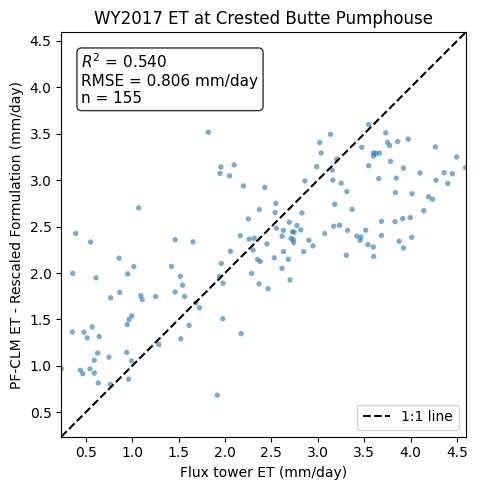

In [46]:
########### find daily ET and align to available station dates
wy_start = pd.Timestamp(f'{water_year - 1}-10-01')
wy_end = pd.Timestamp(f'{water_year}-09-30')
num_days = (wy_end - wy_start).days + 1
available_pf_days = min(num_days, (len(pf_et) - 1) // 24)

pf_et_daily = np.zeros(available_pf_days)
for day in range(available_pf_days):
    t = 1 + day * 24
    pf_et_daily[day] = np.sum(pf_et[t:t+24])

pf_daily = pd.DataFrame({
    'DAY_MT': pd.date_range(wy_start, periods=available_pf_days, freq='D'),
    'PF_ET': pf_et_daily,
})

EC_data_wy = EC_data_wy.copy()
EC_data_wy['ET'] = pd.to_numeric(EC_data_wy['ET'], errors='coerce')
EC_data_wy.loc[EC_data_wy['ET'] == -9999, 'ET'] = np.nan

comparison = EC_data_wy[['DAY_MT', 'ET']].merge(
    pf_daily,
    on='DAY_MT',
    how='inner',
)

if comparison.empty:
    raise ValueError(
        f"No overlapping station and PF dates for WY{water_year}."
    )

print(
    f"Using station/PF overlap from "
    f"{comparison['DAY_MT'].min().date()} to "
    f"{comparison['DAY_MT'].max().date()} "
    f"({len(comparison)} days)."
)

x_all = comparison["ET"].to_numpy(copy=True)
y_all = comparison["PF_ET"].to_numpy(copy=True)

############ comparison plots
fig, ax = plt.subplots()
ax.plot(comparison['DAY_MT'], y_all, label = 'PF-CLM')
ax.plot(comparison['DAY_MT'], x_all, label = 'Flux Tower')
ax.set_ylabel('ET (mm/day)')
ax.legend()
ax.set_title(f'WY{water_year} ET at Crested Butte Pumphouse')
fig.autofmt_xdate()
plt.tight_layout()
plt.savefig(f'~/model_validation/timeseries_{water_year}.png')
plt.close(fig)

# Retain only observations where both values are finite
valid = np.isfinite(x_all) & np.isfinite(y_all)
x = x_all[valid]
y = y_all[valid]

if len(x) == 0:
    raise ValueError(
        f"No finite paired station/PF ET values for WY{water_year}."
    )

r2 = r2_score(x, y)
rmse = np.sqrt(mean_squared_error(x, y))

lower = min(x.min(), y.min())
upper = max(x.max(), y.max())

fig, ax = plt.subplots(figsize=(5,5))

ax.scatter(
    x,
    y,
    s=15,
    alpha=0.6,
    edgecolors="none",
)

# 1:1 line
ax.plot(
    [lower, upper],
    [lower, upper],
    linestyle="--",
    color="black",
    linewidth=1.5,
    label="1:1 line",
)

ax.text(
    0.05,
    0.95,
    f"$R^2$ = {r2:.3f}\nRMSE = {rmse:.3f} mm/day\nn = {len(x)}",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=11,
    bbox={
        "facecolor": "white",
        "edgecolor": "black",
        "alpha": 0.8,
        "boxstyle": "round,pad=0.3",
    },
)

ax.set_xlim(lower, upper)
ax.set_ylim(lower, upper)
ax.set_aspect("equal", adjustable="box")

ax.set_xlabel("Flux tower ET (mm/day)")
ax.set_ylabel("PF-CLM ET - Rescaled Formulation (mm/day)")
ax.set_title(f'WY{water_year} ET at Crested Butte Pumphouse')
ax.legend()

plt.tight_layout()
plt.savefig(f'~/model_validation/correlation_{water_year}.png')

In [47]:
water_year = 2017
runname = 'baseline_rz0.wy2017'

In [48]:
########## subset the flux data to the right water year
EC_data['DAY_MT'] = pd.to_datetime(EC_data['DAY_MT'])

EC_data_wy = EC_data[(EC_data['DAY_MT'] >= pd.to_datetime(f'{water_year - 1}-10-01')) & (EC_data['DAY_MT'] <= pd.to_datetime(f'{water_year}-09-30'))]

######## get pf out ET from run
path_run = f'~/{runname}/'

run = Run.from_definition(f'{path_run}{runname}.pfidb')

data = run.data_accessor # creating data accessor object 
dx = data.dx
dy = data.dy
dz = data.dz

nz,ny,nx = data.shape
mask = data.mask
mask[mask>0]=1 # PF has big # instead of 1 so change to 1 bc more manageable
surf_mask = mask[-1,:,:] # last element of first axis (always be surface no matter what)
nanmask=mask.copy()
nanmask[nanmask == 0] = 'NaN'
nanmask[nanmask > 0] = 1

# for converting from LE to ET
rho_w = 1000 # kg/m3
h_vap_wrong = 22.6*10**5 # J/kg
hvap   = 2.5104e06

num_tsteps = 8760+1

pf_et = np.zeros(num_tsteps)

for t in range(0,num_tsteps):
    data.time = t

    
    if t > 0: 
        pf_et[t] = data.clm_output('eflx_lh_tot', layer = -1)[ec_ij_coords[1], ec_ij_coords[0]] * (1 / rho_w) * (1 / hvap)*3600*1000  # converting from m/s to mm/hr 

np.save(f"~/model_validation/pf_et_EC_{runname}", pf_et)


Solver: Field BinaryOutDir is not part of the expected schema <class 'parflow.tools.database.generated.Solver'>
  - nt
  - sw_ini
  - hkdepth
  - wtfact
  - trsmx0
  - smpmax
  - pondmx


/home/ad4430/.local/lib/python3.9/site-packages/parflow/tools/io.py:1300: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_name, delim_whitespace=True, skiprows=2, header=None)


Using station/PF overlap from 2017-04-15 to 2017-09-30 (169 days).


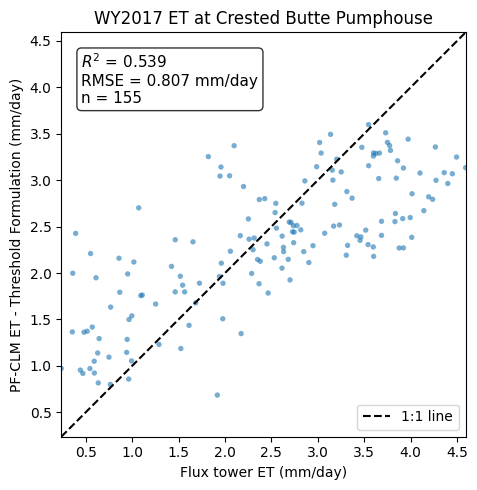

In [49]:
########### find daily ET and align to available station dates
wy_start = pd.Timestamp(f'{water_year - 1}-10-01')
wy_end = pd.Timestamp(f'{water_year}-09-30')
num_days = (wy_end - wy_start).days + 1
available_pf_days = min(num_days, (len(pf_et) - 1) // 24)

pf_et_daily = np.zeros(available_pf_days)
for day in range(available_pf_days):
    t = 1 + day * 24
    pf_et_daily[day] = np.sum(pf_et[t:t+24])

pf_daily = pd.DataFrame({
    'DAY_MT': pd.date_range(wy_start, periods=available_pf_days, freq='D'),
    'PF_ET': pf_et_daily,
})

EC_data_wy = EC_data_wy.copy()
EC_data_wy['ET'] = pd.to_numeric(EC_data_wy['ET'], errors='coerce')
EC_data_wy.loc[EC_data_wy['ET'] == -9999, 'ET'] = np.nan

comparison = EC_data_wy[['DAY_MT', 'ET']].merge(
    pf_daily,
    on='DAY_MT',
    how='inner',
)

if comparison.empty:
    raise ValueError(
        f"No overlapping station and PF dates for WY{water_year}."
    )

print(
    f"Using station/PF overlap from "
    f"{comparison['DAY_MT'].min().date()} to "
    f"{comparison['DAY_MT'].max().date()} "
    f"({len(comparison)} days)."
)

x_all = comparison["ET"].to_numpy(copy=True)
y_all = comparison["PF_ET"].to_numpy(copy=True)

############ comparison plots
fig, ax = plt.subplots()
ax.plot(comparison['DAY_MT'], y_all, label = 'PF-CLM')
ax.plot(comparison['DAY_MT'], x_all, label = 'Flux Tower')
ax.set_ylabel('ET (mm/day)')
ax.legend()
ax.set_title(f'WY{water_year} ET at Crested Butte Pumphouse')
fig.autofmt_xdate()
plt.tight_layout()
plt.savefig(f'~/model_validation/timeseries_{water_year}.png')
plt.close(fig)

# Retain only observations where both values are finite
valid = np.isfinite(x_all) & np.isfinite(y_all)
x = x_all[valid]
y = y_all[valid]

if len(x) == 0:
    raise ValueError(
        f"No finite paired station/PF ET values for WY{water_year}."
    )

r2 = r2_score(x, y)
rmse = np.sqrt(mean_squared_error(x, y))

lower = min(x.min(), y.min())
upper = max(x.max(), y.max())

fig, ax = plt.subplots(figsize=(5,5))

ax.scatter(
    x,
    y,
    s=15,
    alpha=0.6,
    edgecolors="none",
)

# 1:1 line
ax.plot(
    [lower, upper],
    [lower, upper],
    linestyle="--",
    color="black",
    linewidth=1.5,
    label="1:1 line",
)

ax.text(
    0.05,
    0.95,
    f"$R^2$ = {r2:.3f}\nRMSE = {rmse:.3f} mm/day\nn = {len(x)}",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=11,
    bbox={
        "facecolor": "white",
        "edgecolor": "black",
        "alpha": 0.8,
        "boxstyle": "round,pad=0.3",
    },
)

ax.set_xlim(lower, upper)
ax.set_ylim(lower, upper)
ax.set_aspect("equal", adjustable="box")

ax.set_xlabel("Flux tower ET (mm/day)")
ax.set_ylabel("PF-CLM ET - Threshold Formulation (mm/day)")
ax.set_title(f'WY{water_year} ET at Crested Butte Pumphouse')
ax.legend()

plt.tight_layout()
plt.savefig(f'~/model_validation/correlation_{water_year}_rz0.png')

# wy2018

In [50]:
water_year = 2018
runname = 'baseline.wy2018'

In [51]:
########## subset the flux data to the right water year
EC_data['DAY_MT'] = pd.to_datetime(EC_data['DAY_MT'])

EC_data_wy = EC_data[(EC_data['DAY_MT'] >= pd.to_datetime(f'{water_year - 1}-10-01')) & (EC_data['DAY_MT'] <= pd.to_datetime(f'{water_year}-09-30'))]

######## get pf out ET from run
path_run = f'~/{runname}/'

run = Run.from_definition(f'{path_run}{runname}.pfidb')

data = run.data_accessor # creating data accessor object 
dx = data.dx
dy = data.dy
dz = data.dz

nz,ny,nx = data.shape
mask = data.mask
mask[mask>0]=1 # PF has big # instead of 1 so change to 1 bc more manageable
surf_mask = mask[-1,:,:] # last element of first axis (always be surface no matter what)
nanmask=mask.copy()
nanmask[nanmask == 0] = 'NaN'
nanmask[nanmask > 0] = 1

# for converting from LE to ET
rho_w = 1000 # kg/m3
h_vap_wrong = 22.6*10**5 # J/kg
hvap   = 2.5104e06

num_tsteps = 8760+1

pf_et = np.zeros(num_tsteps)

for t in range(0,num_tsteps):
    data.time = t

    
    if t > 0: 
        pf_et[t] = data.clm_output('eflx_lh_tot', layer = -1)[ec_ij_coords[1], ec_ij_coords[0]] * (1 / rho_w) * (1 / hvap)*3600*1000  # converting from m/s to mm/hr 

np.save(f"~/model_validation/pf_et_EC_{runname}", pf_et)


Solver: Field BinaryOutDir is not part of the expected schema <class 'parflow.tools.database.generated.Solver'>
  - nt
  - sw_ini
  - hkdepth
  - wtfact
  - trsmx0
  - smpmax
  - pondmx


/home/ad4430/.local/lib/python3.9/site-packages/parflow/tools/io.py:1300: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_name, delim_whitespace=True, skiprows=2, header=None)


Using station/PF overlap from 2017-10-01 to 2018-09-30 (365 days).


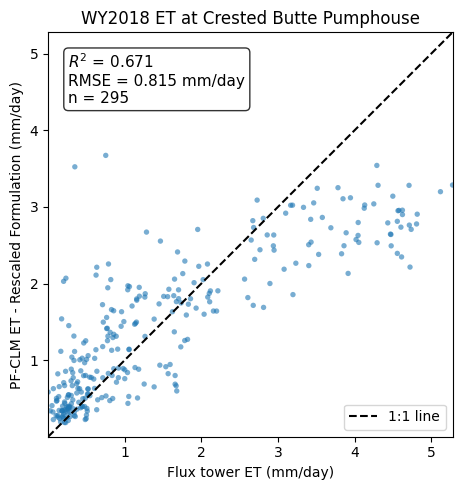

In [52]:
########### find daily ET and align to available station dates
wy_start = pd.Timestamp(f'{water_year - 1}-10-01')
wy_end = pd.Timestamp(f'{water_year}-09-30')
num_days = (wy_end - wy_start).days + 1
available_pf_days = min(num_days, (len(pf_et) - 1) // 24)

pf_et_daily = np.zeros(available_pf_days)
for day in range(available_pf_days):
    t = 1 + day * 24
    pf_et_daily[day] = np.sum(pf_et[t:t+24])

pf_daily = pd.DataFrame({
    'DAY_MT': pd.date_range(wy_start, periods=available_pf_days, freq='D'),
    'PF_ET': pf_et_daily,
})

EC_data_wy = EC_data_wy.copy()
EC_data_wy['ET'] = pd.to_numeric(EC_data_wy['ET'], errors='coerce')
EC_data_wy.loc[EC_data_wy['ET'] == -9999, 'ET'] = np.nan

comparison = EC_data_wy[['DAY_MT', 'ET']].merge(
    pf_daily,
    on='DAY_MT',
    how='inner',
)

if comparison.empty:
    raise ValueError(
        f"No overlapping station and PF dates for WY{water_year}."
    )

print(
    f"Using station/PF overlap from "
    f"{comparison['DAY_MT'].min().date()} to "
    f"{comparison['DAY_MT'].max().date()} "
    f"({len(comparison)} days)."
)

x_all = comparison["ET"].to_numpy(copy=True)
y_all = comparison["PF_ET"].to_numpy(copy=True)

############ comparison plots
fig, ax = plt.subplots()
ax.plot(comparison['DAY_MT'], y_all, label = 'PF-CLM')
ax.plot(comparison['DAY_MT'], x_all, label = 'Flux Tower')
ax.set_ylabel('ET (mm/day)')
ax.legend()
ax.set_title(f'WY{water_year} ET at Crested Butte Pumphouse')
fig.autofmt_xdate()
plt.tight_layout()
plt.savefig(f'~/model_validation/timeseries_{water_year}.png')
plt.close(fig)

# Retain only observations where both values are finite
valid = np.isfinite(x_all) & np.isfinite(y_all)
x = x_all[valid]
y = y_all[valid]

if len(x) == 0:
    raise ValueError(
        f"No finite paired station/PF ET values for WY{water_year}."
    )

r2 = r2_score(x, y)
rmse = np.sqrt(mean_squared_error(x, y))

lower = min(x.min(), y.min())
upper = max(x.max(), y.max())

fig, ax = plt.subplots(figsize=(5, 5))

ax.scatter(
    x,
    y,
    s=15,
    alpha=0.6,
    edgecolors="none",
)

# 1:1 line
ax.plot(
    [lower, upper],
    [lower, upper],
    linestyle="--",
    color="black",
    linewidth=1.5,
    label="1:1 line",
)

ax.text(
    0.05,
    0.95,
    f"$R^2$ = {r2:.3f}\nRMSE = {rmse:.3f} mm/day\nn = {len(x)}",
    transform=ax.transAxes,
    ha="left",
    va="top",
    fontsize=11,
    bbox={
        "facecolor": "white",
        "edgecolor": "black",
        "alpha": 0.8,
        "boxstyle": "round,pad=0.3",
    },
)

ax.set_xlim(lower, upper)
ax.set_ylim(lower, upper)
ax.set_aspect("equal", adjustable="box")

ax.set_xlabel("Flux tower ET (mm/day)")
ax.set_ylabel("PF-CLM ET - Rescaled Formulation (mm/day)")
ax.set_title(f'WY{water_year} ET at Crested Butte Pumphouse')
ax.legend()

plt.tight_layout()
plt.savefig(f'~/model_validation/correlation_{water_year}.png')

# combined figure

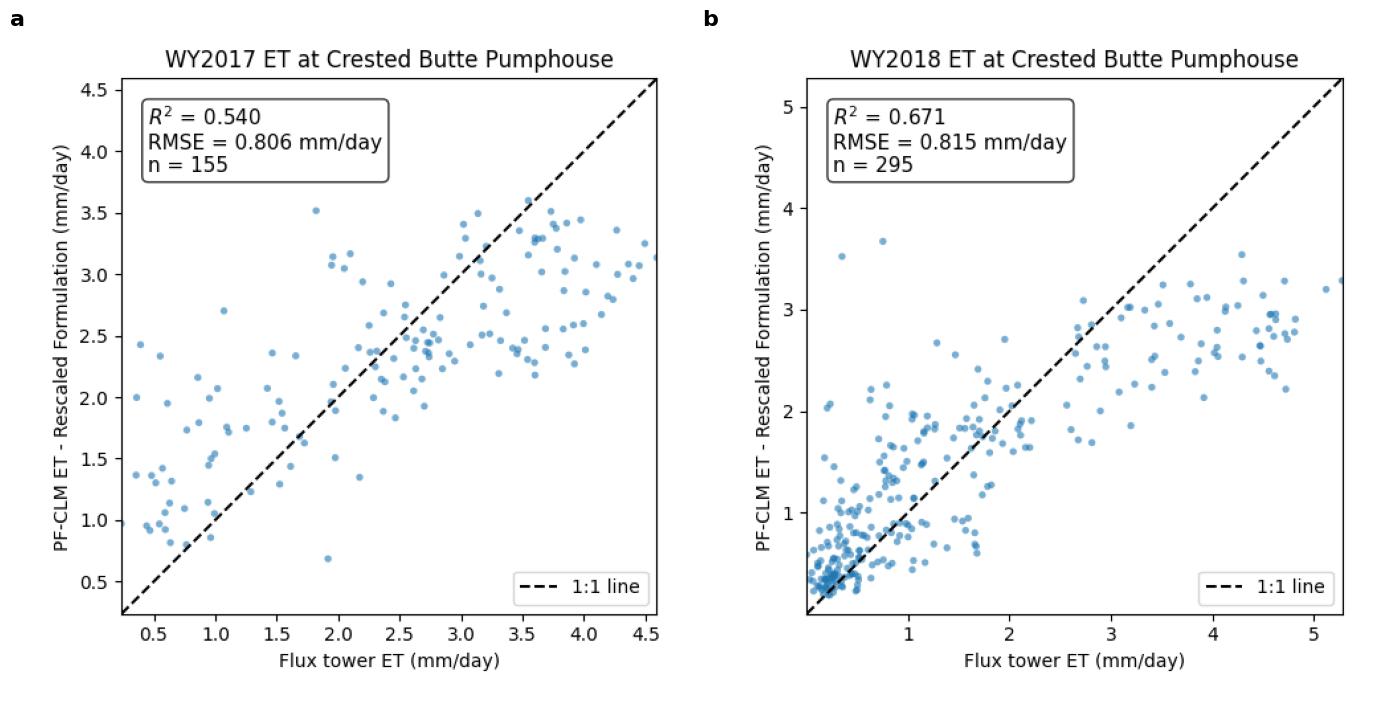

In [60]:
img_2017     = plt.imread('~/model_validation/correlation_2017.png')
img_2018     = plt.imread('~/model_validation/correlation_2018.png')


# -------------------- Figure --------------------

fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 12)
)

images = [
    img_2017,
    img_2018
]

panel_labels = ['a', 'b']

for ax, img, label in zip(axes.flat, images, panel_labels):

    ax.imshow(img)
    ax.axis('off')

    # Panel label in upper-left
    ax.text(
        -0.001, 1,
        label,
        transform=ax.transAxes,
        fontsize=16,
        fontweight='bold',
        ha='right',
        va='bottom'
    )


plt.tight_layout()
plt.show()